In [32]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score ,median_absolute_error,explained_variance_score)


In [33]:
df = pd.read_csv('housing.csv')

In [34]:
df.shape

(20640, 10)

In [35]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [36]:
# ocean_proximity is text → convert to numbers
df['ocean_proximity'] = df['ocean_proximity'].astype('category').cat.codes

In [37]:
df.dropna(inplace=True)           # remove rows with missing values

In [38]:
df.shape

(20433, 10)

In [39]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


### TASK 1 – Build a Baseline Linear Regression Model

In [40]:
x = df[['median_income']]
y = df[['median_house_value']]

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
model= LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred = model.predict(x_test)

In [44]:
#  Calculate error metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
 
print(f"\nMSE  (Mean Squared Error)      : {mse:,.2f}")
print(f"RMSE (Root Mean Squared Error) : {rmse:,.2f}")
print(f"MAE  (Mean Absolute Error)     : {mae:,.2f}")
print(f"R²   (R-squared)               : {r2:.4f}")


MSE  (Mean Squared Error)      : 7,221,011,204.24
RMSE (Root Mean Squared Error) : 84,976.53
MAE  (Mean Absolute Error)     : 63,374.55
R²   (R-squared)               : 0.4720


In [45]:

comparision = pd.DataFrame({
    'Actual': y_test.values[:10].flatten(),
    'Predicted': y_pred[:10].flatten().round(2)
})

comparision.index = range(1, 11)
comparision

,Actual,Predicted
1,245800.0,177965.11
2,137900.0,232380.44
3,218200.0,179631.02
4,220800.0,165781.89
5,170500.0,216285.06
6,75000.0,130104.84
7,269400.0,264349.91
8,228900.0,249227.35
9,500001.0,363306.23
10,80800.0,133758.14


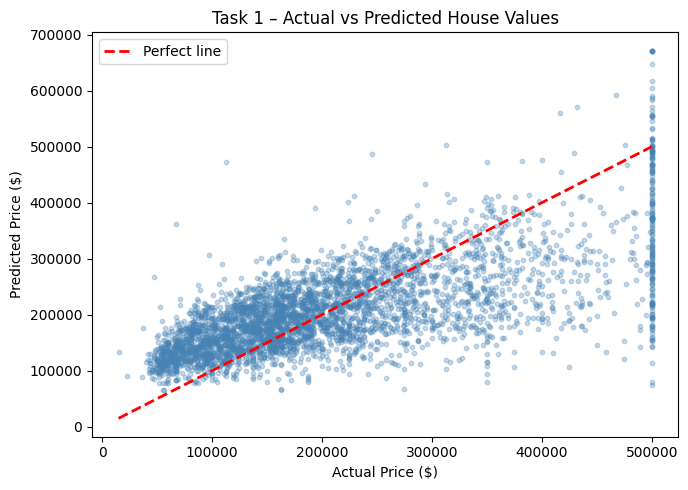

In [50]:

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect line')

plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Task 1 – Actual vs Predicted House Values')
plt.legend()
plt.tight_layout()
plt.show()

---
### Task 2: Compare one-feature and multi-feature models

In [51]:
y = df['median_house_value']

# Model A – only 1 feature
X_a = df[['median_income']]

In [52]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y, test_size=0.2, random_state=42
)


In [53]:
model_a = LinearRegression()
model_a.fit(X_train_a, y_train_a)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
pred_a = model_a.predict(X_test_a)
print('Model A trained with 1 feature!')

Model A trained with 1 feature!


In [56]:
# Model B – 6 features
X_b = df[[
    'median_income',
    'housing_median_age',
    'total_rooms',
    'latitude',
    'longitude',
    'ocean_proximity'
]]

In [57]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y, test_size=0.2, random_state=42
)

In [58]:
model_b = LinearRegression()
model_b.fit(X_train_b, y_train_b)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
pred_b = model_b.predict(X_test_b)

print('Model B trained with 6 features')

Model B trained with 6 features


In [64]:
# Helper function to get all metrics at once
def get_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

mA = get_metrics(y_test_a, pred_a)
mB = get_metrics(y_test_b, pred_b)

In [66]:
# comparison table
compare_df = pd.DataFrame({
    'Metric'            : ['MSE', 'RMSE', 'MAE', 'R²'],
    'Model A (1 feature)': [round(x, 4) for x in mA],
    'Model B (6 features)': [round(x, 4) for x in mB]
})

print(compare_df.to_string(index=False))
print()

if mB[3] > mA[3]:
    print(f' Model B is BETTER  R² improved by: {mB[3] - mA[3]:.4f}')
else:
    print(' Model A is BETTER')

Metric  Model A (1 feature)  Model B (6 features)
   MSE         7.221011e+09          5.500215e+09
  RMSE         8.497653e+04          7.416344e+04
   MAE         6.337455e+04          5.474157e+04
    R²         4.720000e-01          5.978000e-01

 Model B is BETTER  R² improved by: 0.1258


----
## Task 3: Test different train/test splits

> Run Model on 3 Different Splits

In [73]:
X = df[['median_income', 'housing_median_age', 'total_rooms',
        'latitude', 'longitude', 'ocean_proximity']]
y = df['median_house_value']   


In [74]:
# 80/20 | 70/30 | 60/40
splits  = [0.20, 0.30, 0.40] 

results = []

for test_size in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    m = LinearRegression()
    m.fit(X_train, y_train)

    # Training metrics (how well it learned)
    train_pred = m.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2   = r2_score(y_train, train_pred)

    # Testing metrics (how well it predicts new data)
    test_pred = m.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2   = r2_score(y_test, test_pred)

    results.append({
        'Split'      : f"{int((1-test_size)*100)}/{int(test_size*100)}",
        'Train RMSE' : round(train_rmse, 2),
        'Test RMSE'  : round(test_rmse,  2),
        'Train R²'   : round(train_r2,   4),
        'Test R²'    : round(test_r2,    4),
        'Gap (R²)'   : round(train_r2 - test_r2, 4)
    })


In [75]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['Test R²'].idxmax(), 'Split']
print(f'\n Best split: {best}  (highest Test R²)')

Split  Train RMSE  Test RMSE  Train R²  Test R²  Gap (R²)
80/20    72990.69   74163.44    0.5975   0.5978   -0.0003
70/30    73390.53   72851.08    0.5957   0.6019   -0.0062
60/40    73880.71   72248.87    0.5939   0.6031   -0.0092

 Best split: 60/40  (highest Test R²)


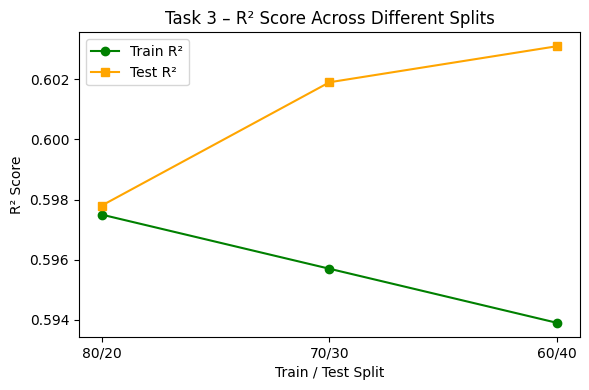

In [76]:
plt.figure(figsize=(6, 4))

plt.plot(results_df['Split'], results_df['Train R²'],
         marker='o', label='Train R²', color='green')
plt.plot(results_df['Split'], results_df['Test R²'],
         marker='s', label='Test R²',  color='orange')

plt.xlabel('Train / Test Split')
plt.ylabel('R² Score')
plt.title('Task 3 – R² Score Across Different Splits')
plt.legend()
plt.tight_layout()
plt.show()

## Task 4: Metric verification and exploration
> Train the Best Model

In [78]:
X = df[['median_income', 'housing_median_age', 'total_rooms',
        'latitude', 'longitude', 'ocean_proximity']]
y = df['median_house_value']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [82]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
y_pred = best_model.predict(X_test)

In [84]:
#  sklearn functions
sk_mse  = mean_squared_error(y_test, y_pred)
sk_rmse = np.sqrt(sk_mse)
sk_mae  = mean_absolute_error(y_test, y_pred)
sk_r2   = r2_score(y_test, y_pred)

# sklearn Metrics 
print(f'MSE  : {sk_mse:,.2f}')
print(f'RMSE : {sk_rmse:,.2f}')
print(f'MAE  : {sk_mae:,.2f}')
print(f'R²   : {sk_r2:.4f}')

MSE  : 5,500,215,165.53
RMSE : 74,163.44
MAE  : 54,741.57
R²   : 0.5978


In [85]:
# Calculate manually using formulas

 # difference between actual and predicted
errors   = y_test.values - y_pred 

# average of squared errors
man_mse  = np.mean(errors ** 2) 

# square root of MSE
man_rmse = np.sqrt(man_mse)

# average of absolute errors
man_mae  = np.mean(np.abs(errors))          

# sum of squared residuals
ss_res   = np.sum(errors ** 2) 

 # total variance
ss_tot   = np.sum((y_test.values - y_test.mean()) ** 2) 

 # R² formula
man_r2   = 1 - (ss_res / ss_tot)          

In [86]:
print(f'MSE  : {man_mse:,.2f}')
print(f'RMSE : {man_rmse:,.2f}')
print(f'MAE  : {man_mae:,.2f}')
print(f'R²   : {man_r2:.4f}')

MSE  : 5,500,215,165.53
RMSE : 74,163.44
MAE  : 54,741.57
R²   : 0.5978


In [90]:
print(f"{'Metric':<8} {'sklearn':>15} {'Manual':>20} {'Match?':>10}")
print('-' * 50)

for name, sk, mn in [('MSE',  sk_mse,  man_mse),
                     ('RMSE', sk_rmse, man_rmse),
                     ('MAE',  sk_mae,  man_mae),
                     ('R²',   sk_r2,   man_r2)]:
    match = 'match' if abs(sk - mn) < 0.01 else 'not match'
    print(f"{name:<8} {sk:>15,.4f} {mn:>20,.4f} {match:>10}")

Metric           sklearn               Manual     Match?
--------------------------------------------------
MSE      5,500,215,165.5285   5,500,215,165.5285      match
RMSE         74,163.4355          74,163.4355      match
MAE          54,741.5671          54,741.5671      match
R²                0.5978               0.5978      match


### Extra Metrics

In [91]:
med_ae  = median_absolute_error(y_test, y_pred)
exp_var = explained_variance_score(y_test, y_pred)



In [92]:

print(f'MSE                   : {sk_mse:>15,.2f}')
print(f'RMSE                  : {sk_rmse:>15,.2f}')
print(f'MAE                   : {sk_mae:>15,.2f}')
print(f'R²                    : {sk_r2:>15.4f}')
print(f'Median Absolute Error : {med_ae:>15,.2f}')
print(f'Explained Variance    : {exp_var:>15.4f}')

MSE                   : 5,500,215,165.53
RMSE                  :       74,163.44
MAE                   :       54,741.57
R²                    :          0.5978
Median Absolute Error :       43,730.13
Explained Variance    :          0.5979


In [93]:
# Add 3 very large fake errors to see how each metric reacts
y_pred_bad = y_pred.copy()
y_pred_bad[0] += 500_000   # error 1
y_pred_bad[1] -= 400_000   # error 2
y_pred_bad[2] += 600_000   # error 3

In [94]:
c_mse  = mean_squared_error(y_test, y_pred_bad)
c_rmse = np.sqrt(c_mse)
c_mae  = mean_absolute_error(y_test, y_pred_bad)


In [96]:
print(f"{'Metric':<8} {'Before':>15} {'After':>15} {'Change %':>10}")
print('-' * 52)

for name, before, after in [('MSE',  sk_mse,  c_mse),
                             ('RMSE', sk_rmse, c_rmse),
                             ('MAE',  sk_mae,  c_mae)]:
    pct = (after - before) / before * 100
    print(f"{name:<8} {before:>15,.2f} {after:>15,.2f} {pct:>9.1f}%")

print()
print('   MSE jumps the most because it SQUARES the errors.')
print('   MAE changes the least because it treats all errors equally.')

Metric            Before           After   Change %
----------------------------------------------------
MSE      5,500,215,165.53 5,660,283,306.99       2.9%
RMSE           74,163.44       75,234.85       1.4%
MAE            54,741.57       55,049.32       0.6%

   MSE jumps the most because it SQUARES the errors.
   MAE changes the least because it treats all errors equally.
